In [ ]:
%pip install flash-attn --no-build-isolation
!pip install transformers==4.46.3 accelerate==1.0.1
%pip install decord ffmpeg-python imageio opencv-python matplotlib
%pip install -U bitsandbytes

## Model

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoProcessor

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_path = "DAMO-NLP-SG/VideoLLaMA3-7B"
# model_path = "DAMO-NLP-SG/VideoLLaMA3-2B"
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    trust_remote_code=True,
    device_map={"": device},
    torch_dtype=torch.bfloat16,
    # quantization_config=bnb_config,
    attn_implementation="flash_attention_2",
)
processor = AutoProcessor.from_pretrained(model_path, trust_remote_code=True)

Loading checkpoint shards: 100%|██████████| 4/4 [00:13<00:00,  3.48s/it]


In [4]:
print(device)
model = model.to(device)
model.device

cuda:0


device(type='cuda', index=0)

In [5]:
from torch.utils.data import DataLoader
from data_load import PHOLPhysicsDataset

root = "path_to_the_data"


def collate_fn(batch):
    return {
        "scene_id": [item["scene_id"] for item in batch],
        "video": torch.stack([item["video"] for item in batch]),
        "qa": [item["qa"] for item in batch],
        "physical_props": [item["physical_props"] for item in batch],
        "taxonomy": [item["taxonomy"] for item in batch],
    }


dataset = PHOLPhysicsDataset(root=root, include_qa=True)
dataloader = DataLoader(
    dataset,
    batch_size=1,
    # shuffle=True,
    collate_fn=collate_fn,
)

all_dirs 4000
valid 4000
numeric 4000
non_numeric 0
 self.scenes  4000 0


In [6]:
# AGENET_MEAN = (0.485, 0.456, 0.406)
# IMAGENET_STD  = (0.229, 0.224, 0.225)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


def build_transform(size):
    return T.Compose(
        [
            T.Lambda(lambda img: img.convert("RGB") if img.mode != "RGB" else img),
            T.Resize((size, size), interpolation=InterpolationMode.BICUBIC),
            T.ToTensor(),
            T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]
    )


def load_video_frames_opencv(
    path, expected_time=None, fps=25, num_segments=32, input_size=448
):
    cap = cv2.VideoCapture(path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    seg_size = max(total_frames // num_segments, 1)
    idxs = [i * seg_size for i in range(num_segments)]

    transform = build_transform(input_size)
    frames = []
    for target_idx in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, target_idx)
        ret, frame = cap.read()
        if not ret:
            continue
        img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        # frames.append(img.unsqueeze(0))
        frames.append(transform(img).unsqueeze(0))
    # frames.append(img.unsqueeze(0))

    cap.release()
    pixel_values = (
        torch.cat(frames, dim=0)
        if frames
        else torch.zeros(1, 3, input_size, input_size)
    )
    num_patches = [1] * pixel_values.shape[0]
    return pixel_values, num_patches


def assess_response(prediction, ground_truth):
    # assessment with keyword matching and numeric comparison
    # numeric
    if any(word in ground_truth.lower() for word in ["mass", "friction", "velocity"]):
        try:
            gt_num = float("".join(c for c in ground_truth if c.isdigit() or c == "."))
            pred_num = float("".join(c for c in prediction if c.isdigit() or c == "."))
            return 1.0 if abs(gt_num - pred_num) < 0.1 else 0.0
        except:
            return 0.0

    # qualitative questions
    keywords = {
        "collision": ["collide", "impact", "hit"],
        "material": ["made of", "material", "composition"],
        "motion": ["moving", "sliding", "rolling"],
    }

    score = 0
    for category, terms in keywords.items():
        if any(term in ground_truth.lower() for term in terms):
            if any(term in prediction.lower() for term in terms):
                score += 1
    return score / len(keywords)

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
from PIL import Image
import torchvision.transforms as T
from torchvision.transforms.functional import InterpolationMode
import math


def show_video_frames(
    video_path,
    num_segments=32,
    max_cols=8,
    min_cols=4,
    base_figsize=(16, 8),
    max_figsize=(24, 16),
):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video at {video_path}")
        return

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames == 0:
        print(f"Warning: Video at {video_path} has zero frames.")
        cap.release()
        return

    n_cols = min(max_cols, max(min_cols, math.isqrt(num_segments) + 1))
    n_rows = math.ceil(num_segments / n_cols)

    cell_width, cell_height = 3, 3
    fig_width = n_cols * cell_width
    fig_height = n_rows * cell_height
    figsize = (fig_width, fig_height)

    frame_indices = np.linspace(0, total_frames - 1, num_segments, dtype=int)

    frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            print(f"Warning: Could not read frame {idx}. Skipping.")
            continue
        frames.append((idx, cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))

    cap.release()

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    plt.suptitle(
        f"Video frames (total={total_frames}) → showing {len(frames)}/{num_segments} slices",
        fontsize=14,
        y=0.98,
    )

    if isinstance(axes, np.ndarray):
        axes_flat = axes.flatten()
    else:
        axes_flat = [axes]

    for i, (frame_idx, frame_rgb) in enumerate(frames):
        ax = axes_flat[i]
        ax.imshow(frame_rgb)
        ax.set_title(f"Fr.{frame_idx + 1}", fontsize=8)
        ax.axis("off")

    # Hide unused axes
    for j in range(len(frames), len(axes_flat)):
        axes_flat[j].axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [8]:
import torch
from transformers import AutoModelForCausalLM, AutoProcessor


def build_dynamic_prompt(
    video_frames,
    taxonomy={},
    physical_props={},
    question="",
    options=None,
    explanation=None,
    num_patches_video=32,
    video_duration=15.0,
    fps=1,
):
    object_behaviors = []
    behavior_dict = {}

    valid_objects = []
    for obj_id, frame_labels in taxonomy.items():
        all_labels = set(label for labels in frame_labels for label in labels if label)
        if all_labels:
            valid_objects.append((obj_id, all_labels))

    for i, (obj_id, all_labels) in enumerate(valid_objects, start=1):
        props = physical_props.get(obj_id, {})
        desc = f"{props.get('color', 'unknown')} {props.get('shape', 'object')}"
        object_behaviors.append(f"{i}. {desc}: {', '.join(sorted(all_labels))}")
        behavior_dict[obj_id] = {
            "description": desc,
            "behaviors": all_labels,
            "properties": props,
            "number": i,
        }

    behavior_context = (
        "\n".join(object_behaviors)
        if object_behaviors
        else "No behavior labels available"
    )

    if physical_props:
        physical_props_str = "\n".join(
            f"{i + 1}. {v['color']} {v['shape']}: mass={v['mass']}, friction={v['friction'][0]:.2f}"
            for i, (k, v) in enumerate(physical_props.items())
        )
    else:
        physical_props_str = "No physical properties available"

    additional_information = ""
    if options:
        additional_information = f"\nHere are some options and you need to pick one based on your beliefs and calculations. Options: {options}\n"

    explanation_info = ""
    if explanation:
        explanation_info = f"\nHere is explanation how to calculate- {explanation}"

    reasoning_rules = [
        "1. Cross-reference visual evidence with the reported object behaviors",
        "2. Consider how physical properties affect the observed behaviors",
        "3. Analyze interactions between objects based on their behavior labels",
    ]
    if behavior_dict:
        specific_rules = [
            "4. For questions about motion, check behaviors containing 'moving', 'sliding', or 'rolling'",
            "5. For collision questions, verify labels containing 'collision' or 'contact'",
        ]
        reasoning_rules.extend(specific_rules)
    reasoning_instructions = "\n".join(reasoning_rules)
    return f"""
   Physics Video Analysis Instruction

Answer the question using ONLY the provided evidence. Follow this strict protocol:

1. QUESTION CLASSIFICATION:
   Match question to these types (regex patterns from your template):
   - contact → "collide" or "contact" in question → yes/no
   - object_count → "How many distinct physical objects" → number
   - stop_count → "come to a complete stop" → number
   - rolling_count → "display rolling motion" → number
   - collision_objs → "unique objects involved in collision" → number
   - top_collider → "most collisions" → exact object name
   - kinetic_loss → "percentage of kinetic energy" → X%
   - collision_duration → "How long did collision" → Xs
   - stationary_time → "seconds spent stationary" → Xs
   - max_friction → "highest friction coefficient" → exact object name
   - yesno → any yes/no question → yes/no
   - count → "How many" → number
   - property → "What is the" → exact value/name

2. EVIDENCE SCANNING:
   - For counts: Check OBJECT BEHAVIORS
   - For properties: Check OBJECT PROPERTIES
   - For collisions: Require ≥2 objects with collision behaviors
   - For energy/time: Use mass + friction + behaviors

3. ANSWER FORMATTING:
   - yes/no → lowercase, no punctuation
   - numbers → digits only (e.g. "3")
   - objects → exact name (e.g. "darkcyan sphere")
   - percentages → "X%" (e.g. "42%")
   - time → "Xs" (e.g. "0.5s")
   - multi-choice → exact option text only

OBJECT PROPERTIES:
{physical_props_str}

OBJECT BEHAVIORS:
{behavior_context}

QUESTION:
{question}{explanation_info}{additional_information}
Answer:
    """


def evaluate_with_dynamic_taxonomy(
    dataloader, model, processor, root, max_samples=5, start_index=0, end_index=1000
):
    results = []
    count = 0
    num_patches_video = 32
    fps = 2

    options = [
        {"is_taxonomy": False, "is_physics": False, "name": "no_additional_info"},
        {"is_taxonomy": True, "is_physics": False, "name": "taxonomy_only"},
        {"is_taxonomy": False, "is_physics": True, "name": "physics_only"},
        {"is_taxonomy": True, "is_physics": True, "name": "taxonomy_and_physics"},
    ]

    # for batch in tqdm(dataloader):
    for batch_idx, batch in enumerate(tqdm(dataloader)):
        batch_size = len(batch["scene_id"])
        current_start = batch_idx * batch_size
        current_end = current_start + batch_size

        # # Skip batches before our start index
        # if current_end <= start_index:
        #     continue

        # # Stop after reaching end index
        # if current_start >= end_index:
        #     break

        if count >= max_samples:
            break
        count += 1

        scene_id = batch["scene_id"][0]
        video_path = f"{root}/{scene_id}/simulation_objects.mp4"

        pixel_values, num_patches = load_video_frames_opencv(
            video_path, num_segments=num_patches_video, input_size=224
        )
        pixel_values = pixel_values.to(model.device, dtype=model.dtype)
        if isinstance(num_patches, torch.Tensor):
            num_patches = num_patches.to(model.device)

        taxonomy = batch["taxonomy"][0]
        physical_props = batch["physical_props"][0]
        qa_pairs = batch["qa"][0]

        for option in options:
            for qa in qa_pairs:
                prompt = build_dynamic_prompt(
                    video_frames=range(len(num_patches)),
                    taxonomy=taxonomy if option["is_taxonomy"] else {},
                    physical_props=physical_props if option["is_physics"] else {},
                    question=qa["question"],
                    options=qa.get("options", None),
                    explanation=qa.get("explanation", None),
                    num_patches_video=num_patches_video,
                    video_duration=15.0,
                    fps=fps,
                )

                # print("prompt", prompt)
                # Prepare conversation for VideoLLaMA3
                conversation = [
                    {"role": "system", "content": "You are a helpful assistant."},
                    {
                        "role": "user",
                        "content": [
                            {
                                "type": "video",
                                "video": {
                                    "video_path": video_path,
                                    "fps": fps,
                                    "max_frames": num_patches_video,
                                },
                            },
                            {"type": "text", "text": prompt},
                        ],
                    },
                ]
                inputs = processor(conversation=conversation, return_tensors="pt")
                inputs = {
                    k: v.to(model.device) if isinstance(v, torch.Tensor) else v
                    for k, v in inputs.items()
                }
                if "pixel_values" in inputs:
                    inputs["pixel_values"] = inputs["pixel_values"].to(torch.bfloat16)

                with torch.no_grad():
                    output_ids = model.generate(
                        **inputs, max_new_tokens=200, do_sample=True, temperature=0.1
                    )
                response = processor.batch_decode(output_ids, skip_special_tokens=True)[
                    0
                ].strip()
                # print("qa", qa['question'])
                # print("response", response)
                # print("qa['answer']", qa['answer'])
                # print("+++++"*10)
                eval_res = evaluate_response_quality(
                    response, qa["answer"], taxonomy, physical_props
                )

                results.append(
                    {
                        "scene_id": scene_id,
                        "question": qa["question"],
                        "answer": qa["answer"],
                        "options": qa.get("options", None),
                        "response": response,
                        "correct": eval_res["correct"],
                        "error": eval_res["error"],
                        "option": option["name"],
                    }
                )
    return results

In [9]:
def evaluate_response_quality(response, true_answer, taxonomy, physical_props):
    def normalize_answer(ans):
        """Normalize answers for comparison"""
        if isinstance(ans, (list, tuple)):
            return [str(a).strip().lower() for a in ans]
        if isinstance(ans, (int, float)):
            return [str(float(ans))]
        ans = str(ans).strip().lower()
        if ans.startswith("no collision"):
            return ["0"]
        if ans in ["no collisions detected", "none"]:
            return ["0"]
        if ans.startswith("yes"):
            return ["yes"]
        if ans.startswith("no"):
            return ["no"]
        # Handle percentage and time strings
        if "%" in ans:
            ans = ans.replace("%", "")
        if ans.endswith("s") and ans[:-1].replace(".", "").isdigit():
            ans = ans[:-1]
        # Strip non-digit characters for numeric answers
        ans = "".join(c for c in ans if c.isdigit() or c in [".", "-"])
        return [ans]

    norm_response = normalize_answer(response)
    norm_true = normalize_answer(true_answer)

    if isinstance(true_answer, (list, tuple)) or len(norm_true) > 1:
        for resp_item in norm_response:
            if any(resp_item in true for true in norm_true):
                return {"correct": 1, "error": None}
        return {"correct": 0, "error": "value"}

    try:
        resp_num = float(norm_response[0])
        true_num = float(norm_true[0])
        if abs(resp_num - true_num) <= 0.05 * abs(true_num):
            return {"correct": 1, "error": None}
        return {"correct": 0, "error": "value"}
    except (ValueError, TypeError):
        pass

    if norm_response[0] == norm_true[0]:
        return {"correct": 1, "error": None}

    text_response = str(response).strip().lower()
    text_true = str(true_answer).strip().lower()
    if (text_response in text_true) or (text_true in text_response):
        return {"correct": 1, "error": None}

    special_cases = {"0": ["no collisions detected", "none", "no"], "1": ["yes"]}
    for key, aliases in special_cases.items():
        if (norm_true[0] == key and text_response in aliases) or (
            norm_response[0] == key and text_true in aliases
        ):
            return {"correct": 1, "error": None}

    error_type = "format" if not norm_response[0] else "value"
    return {"correct": 0, "error": error_type}

In [ ]:
from torch.utils.data import Subset

torch.backends.cuda.enable_flash_sdp(True)
torch.cuda.empty_cache()

start_index = 3000
end_index = 4000

subset_indices = list(range(start_index, end_index))
subset_dataset = Subset(dataset, subset_indices)

subset_dataloader = DataLoader(
    subset_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn
)

enhanced_acc = evaluate_with_dynamic_taxonomy(
    subset_dataloader,
    model,
    processor,
    root,
    start_index=start_index,  # 0-based, so 500 means 501st sample
    end_index=end_index,  # process up to but not including index 1000
    max_samples=1500,
)

# evaluate_with_dynamic_taxonomy(dataloader, model, processor, root_path)

  7%|▋         | 67/1000 [47:51<11:08:39, 43.00s/it]

  9%|▉         | 92/1000 [1:06:14<13:26:03, 53.26s/it]

 13%|█▎        | 127/1000 [1:32:48<11:02:32, 45.54s/it]

 24%|██▍       | 245/1000 [2:58:28<8:29:17, 40.47s/it] 

 38%|███▊      | 384/1000 [4:38:51<7:27:47, 43.62s/it] 

 45%|████▌     | 450/1000 [5:24:48<6:22:45, 41.76s/it]

 46%|████▌     | 458/1000 [5:30:11<6:22:10, 42.31s/it]

 51%|█████▏    | 514/1000 [6:12:50<6:10:42, 45.77s/it]

 61%|██████▏   | 613/1000 [7:25:44<4:20:29, 40.39s/it]

In [ ]:
import json

# with open('./llama_socres-1.json', 'w') as f: #0 - 500
# with open('./results/llama_socres-1.0.json', 'w') as f: #0 - 500
# with open('./llama_socres-2.json', 'w') as f: #500 - 1000
# with open('/data/home/eez086/PHLOP/results/llama_socres-3.0.json', 'w') as f: #1000 - 1500
# with open('/data/home/eez086/PHLOP/results/llama_socres-4.0.json', 'w') as f: #1500 - 3000
with open(
    "/data/home/eez086/PHLOP/results/llama_socres-5.0.json", "w"
) as f:  # 3000 - 4000
    # with open('/data/home/eez086/PHLOP/llama_socres-4.json', 'w') as f: # 1500-2000
    # with open('/data/home/eez086/PHLOP/llama_socres-5.json', 'w') as f: # 2000 - 2500
    # with open('/data/home/eez086/PHLOP/llama_socres-6.json', 'w') as f: # 2500 - 3000
    # with open('/data/home/eez086/PHLOP/llama_socres-7.json', 'w') as f: # 3000 - 3500
    # with open('/data/home/eez086/PHLOP/llama_socres-8.json', 'w') as f: # 3500 - 4000
    # with open('/data/home/eez086/PHLOP/llama_socres.json', 'w') as f:
    json.dump(enhanced_acc, f)

In [24]:
import pandas as pd
import json

file_list = [
    "/data/home/eez086/PHLOP/llama_socres-1.json",
    "/data/home/eez086/PHLOP/llama_socres-2.json",
    # "/data/home/eez086/PHLOP/results/llama_socres-3.json",
    # "/data/home/eez086/PHLOP/results/llama_socres-4.json",
    # "/data/home/eez086/PHLOP/results/llama_socres-5.json",
    # "/data/home/eez086/PHLOP/results/llama_socres-6.json",
    # "/data/home/eez086/PHLOP/results/llama_socres-7.json",
    # "/data/home/eez086/PHLOP/results/llama_socres-8.json",
]

dfs = []
# df = pd.DataFrame([pd.read_json(p, lines=True) for p in file_list])
for file in file_list:
    with open(file) as f:
        data = json.load(f)

    # data = pd.read_json(file, lines=True)
    print(type(data))
    dfs.extend(data)
    # break
# df = pd.DataFrame(dfs)
df = dfs
# temp = pd.concat(dfs, ignore_index=True)

<class 'list'>
<class 'list'>


In [26]:
# df.head()
def calculation(array):
    correct = list(filter(lambda x: x["correct"] == 1, array))
    return len(correct) / len(array)


# print(f"accuracy: {len(correct)/total :.2f}")

taxonomy_and_physics = list(
    filter(lambda x: x.get("option", "") == "taxonomy_and_physics", df)
)
no_additional_info = list(
    filter(lambda x: x.get("option", "") == "no_additional_info", df)
)
physics_only = list(filter(lambda x: x.get("option", "") == "physics_only", df))
taxonomy_only = list(filter(lambda x: x.get("option", "") == "taxonomy_only", df))

print(f"taxonomy_and_physics accuracy: {calculation(taxonomy_and_physics):.2f}")
print(f"physics_only accuracy: {calculation(physics_only):.2f}")
print(f"taxonomy_only accuracy: {calculation(taxonomy_only):.2f}")
print(f"no_additional_info accuracy: {calculation(no_additional_info):.2f}")

taxonomy_and_physics accuracy: 0.62
physics_only accuracy: 0.56
taxonomy_only accuracy: 0.55
no_additional_info accuracy: 0.48


In [13]:
enhanced_acc  # with


def calculation(array):
    correct = list(filter(lambda x: x["correct"] == 1, array))
    return len(correct) / len(array)


# print(f"accuracy: {len(correct)/total :.2f}")

taxonomy_and_physics = list(
    filter(lambda x: x.get("option", "") == "taxonomy_and_physics", enhanced_acc)
)
no_additional_info = list(
    filter(lambda x: x.get("option", "") == "no_additional_info", enhanced_acc)
)
physics_only = list(
    filter(lambda x: x.get("option", "") == "physics_only", enhanced_acc)
)
taxonomy_only = list(
    filter(lambda x: x.get("option", "") == "taxonomy_only", enhanced_acc)
)


print(f"taxonomy_and_physics accuracy: {calculation(taxonomy_and_physics):.2f}")
print(f"physics_only accuracy: {calculation(physics_only):.2f}")
print(f"taxonomy_only accuracy: {calculation(taxonomy_only):.2f}")
print(f"no_additional_info accuracy: {calculation(no_additional_info):.2f}")


# total = len(enhanced_acc)
# correct = list(filter(lambda x: x["correct"] == 1, enhanced_acc))
# print(f"accuracy: {len(correct)/total :.2f}")

taxonomy_and_physics accuracy: 0.72
physics_only accuracy: 0.64
taxonomy_only accuracy: 0.69
no_additional_info accuracy: 0.60


In [38]:
list(filter(lambda x: x["correct"] != 1, taxonomy_and_physics))
# taxonomy_and_physics

[{'scene_id': '500',
  'question': 'Are there any moments in the video where two or more objects collide or make physical contact?',
  'answer': 'Yes',
  'options': None,
  'response': 'no',
  'correct': 0,
  'error': 'value',
  'option': 'taxonomy_and_physics'},
 {'scene_id': '500',
  'question': 'Which object was involved in the most collisions with other objects?',
  'answer': 'No collisions detected',
  'options': None,
  'response': 'grey box',
  'correct': 0,
  'error': 'format',
  'option': 'taxonomy_and_physics'},
 {'scene_id': '500',
  'question': 'How many seconds did the tomato sphere spend stationary?',
  'answer': '0.00s',
  'options': ['1.00s', '0.00s', '0.25s', '0.50s'],
  'response': '0.50s',
  'correct': 0,
  'error': 'value',
  'option': 'taxonomy_and_physics'},
 {'scene_id': '501',
  'question': 'How many objects come to a complete stop during the video that we can see?',
  'answer': '0',
  'options': None,
  'response': '2',
  'correct': 0,
  'error': 'value',
  'op

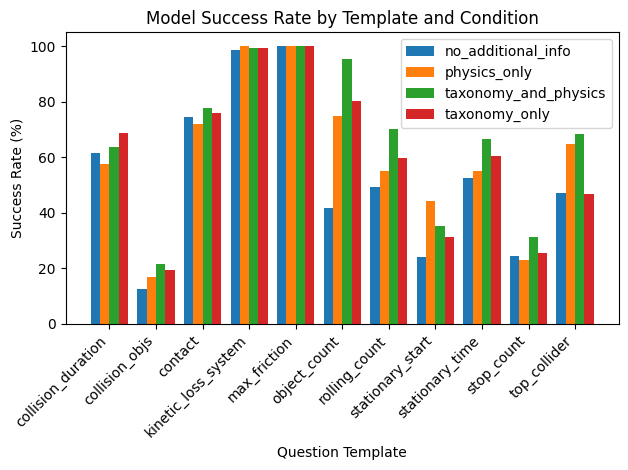

In [28]:
import re

# Build your DataFrame
df = pd.DataFrame(dfs)
# df = pd.DataFrame(enhanced_acc)

# 1) Tag each row with its template, including fallbacks
TEMPLATE_PATTERNS = [
    (
        "contact",
        r"^Are there any moments in the video where two or more objects collide or make physical contact\?$",
    ),
    ("object_count", r"^How many distinct physical objects appear during the video\?$"),
    (
        "stop_count",
        r"^How many objects come to a complete stop during the video that we can see\?$",
    ),
    (
        "rolling_count",
        r"^How many objects display rolling motion at any point in the video\?$",
    ),
    (
        "collision_objs",
        r"^How many unique objects were involved in collision throughout the video\?$",
    ),
    # ("top_collider", r"^Which object(?:\(s\))? were involved in the most collisions with other objects\?$"),
    (
        "top_collider",
        r"^Which object (?:was|were) involved in the most collisions with other objects\?$",
    ),
    # ("kinetic_loss_system",
    #                     r"^What percentage of the system(?:’|'s) kinetic energy was lost when the .+ collided with the .+\?$"),
    (
        "kinetic_loss_system",
        r"^What percentage of the system[’']s kinetic energy was lost when the .+ collided with the .+\?$",
    ),
    # ("kinetic_loss_system",
    #                     r"^What percentage of the system(?:’|'s) kinetic energy was lost when the .+ collided with the .+\?$"),
    (
        "kinetic_loss_obj",
        r"^How much kinetic energy did .+ lose during the collision\?$",
    ),
    # ("collision_duration", r"^How long did the collision between .+ and .+ last \(video fps is \d+\)\\?$"),
    (
        "collision_duration",
        r"^How long did the collision between .+ and .+ last \(video fps is \d+\)\?$",
    ),
    # How long did the collision between darkcyan sphere and hotpink sphere last (video fps is 25)?
    # ("collision_duration",
    #                     r"^How long did the collision between the .+ and the .+ last(?: \(video fps is \d+\))?\?$"),
    ("stationary_time", r"^How many seconds did the .+ spend stationary\?$"),
    (
        "stationary_start",
        r"^At what time in the video does the .+ first become stationary\?$",
    ),
    ("max_friction", r"^Which object had the highest friction coefficient\?$"),
    # FALLBACKS
    ("yesno", r"^(?:Are|Is|Do|Does|Has|Have|Can|Could|Will|Would).*\?$"),
    ("count", r"^How many .+\?$"),
    ("property", r"^What (?:is|are) the .+\?$"),
]
# Which object(s) were involved in the most collisions with other objects?


def assign_template(q):
    for name, pat in TEMPLATE_PATTERNS:
        if re.match(pat, q):
            return name
    print("q", q)
    return "unknown"


df["template"] = df["question"].apply(assign_template)

# 2) (Optionally) inspect how many fell into 'unknown'
n_unknown = (df["template"] == "unknown").sum()
if n_unknown > 0:
    print(
        f"⚠️  {n_unknown} questions didn’t match any pattern and are labeled 'unknown'."
    )

# 3) Drop unknowns before plotting
df = df[df["template"] != "unknown"]

# 4) Summarize and pivot
summary = (
    df.groupby(["template", "option"])
    .agg(n_total=("correct", "count"), n_correct=("correct", "sum"))
    .reset_index()
)
summary["success_pct"] = summary["n_correct"] / summary["n_total"] * 100
pivot = summary.pivot(index="template", columns="option", values="success_pct").fillna(
    0
)

# 5) If pivot is empty, bail out
if pivot.empty:
    print("❗ No templates remained after filtering — check your patterns.")
else:
    # 6) Plot
    labels = pivot.index.tolist()
    x = np.arange(len(labels))
    width = 0.2

    fig, ax = plt.subplots()
    for i, opt in enumerate(pivot.columns):
        ax.bar(x + i * width, pivot[opt], width, label=opt)

    ax.set_xticks(x + width * (len(pivot.columns) - 1) / 2)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_xlabel("Question Template")
    ax.set_ylabel("Success Rate (%)")
    ax.set_title("Model Success Rate by Template and Condition")
    ax.legend()

    plt.tight_layout()
    plt.show()

In [6]:
import torch
from transformers import AutoModelForCausalLM, AutoProcessor

model_path = "DAMO-NLP-SG/VideoLLaMA3-7B-Image"
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    trust_remote_code=True,
    device_map="auto",
    torch_dtype=torch.bfloat16,
    # attn_implementation="flash_attention_2",
)
processor = AutoProcessor.from_pretrained(model_path, trust_remote_code=True)

/data/home/eez086/.conda/envs/flash-attn/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
A new version of the following files was downloaded from https://huggingface.co/DAMO-NLP-SG/VideoLLaMA3-7B-Image:
- configuration_videollama3_encoder.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/DAMO-NLP-SG/VideoLLaMA3-7B-Image:
- modeling_videollama3_encoder.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/DAMO-NLP-SG/VideoLLaMA3-7B-Image:
- configur

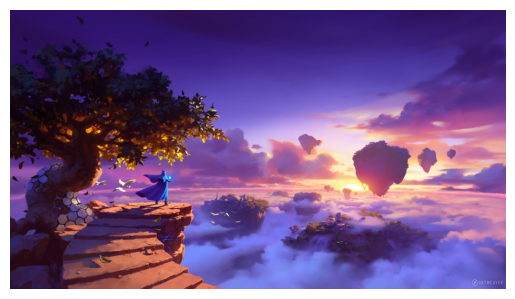

In [7]:
from IPython.display import Markdown, display
import matplotlib.pyplot as plt

image_path = "/data/home/eez086/PHLOP/wallpaper1.jpg"
image = Image.open(image_path).convert("RGB")

plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
conversation = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": {"image_path": image_path}},
            {"type": "text", "text": "What is funny in the image?"},
        ],
    }
]


# Single-turn conversation
inputs = processor(conversation=conversation, return_tensors="pt")
# inputs = {k: v.cuda() if isinstance(v, torch.Tensor) else v for k, v in inputs.items()}
if "pixel_values" in inputs:
    inputs["pixel_values"] = inputs["pixel_values"].to(torch.bfloat16)

output_ids = model.generate(**inputs, max_new_tokens=256)
response = processor.batch_decode(output_ids, skip_special_tokens=True)[0].strip()
display(Markdown(response))